### 랭스미스
- GitHub계정으로 로그인
- Organizations : Personal 무료한도적용
- 왼쪽메뉴[Tracing] 프로젝트 등록 및 클릭 -> .env설정 및 테스트코드로 연결 검증

*** 연결이 안될 때 
- jupyter파일 재시작
- VSCdoe 완전종료 및 재시작

In [ ]:
# !pip --version

pip 26.2.1 from D:\hykim\hanwha_0902\.venv\Lib\site-packages\pip (python 3.12)



In [ ]:
# !pip install -U langchain langchain-openai

In [3]:
from dotenv import load_dotenv
import os

# .env 파일 로드 (override=False가 기본값이므로 시스템 환경변수가 우선순위를 가집니다)
load_dotenv()

# 정상 로드 확인 테스트
print("OPENAI_API_KEY:", os.getenv("OPENAI_API_KEY")[:8] + "...")
print("LANGSMITH_API_KEY:", os.getenv("LANGSMITH_API_KEY")[:8]+"...")
print("LANGSMITH_PROJECT:", os.getenv("LANGSMITH_PROJECT"))
print("LANGSMITH_ENDPOINT:", os.getenv("LANGSMITH_ENDPOINT"))

OPENAI_API_KEY: sk-proj-...
LANGSMITH_API_KEY: lsv2_pt_...
LANGSMITH_PROJECT: hanwha_0902
LANGSMITH_ENDPOINT: https://api.smith.langchain.com


In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
question = "LangChanin에서 LangSmith는 어떻가 사용되나요?"
response = llm.invoke(question)

print(response.content)

# 랭스미스 Tracing에서 확인하기


LangChain은 AI 애플리케이션 개발을 위한 프레임워크로, 다양한 언어 모델 및 도구와의 통합을 지원합니다. LangChain은 데이터 소스 연결, 프롬프트 생성, 체인 구성 및 응답 관리와 같은 기능을 제공하여 개발자가 강력한 AI 솔루션을 구축할 수 있도록 도와줍니다.

LangSmith는 LangChain의 일환으로 사용되는 도구로, 주로 AI 모델의 평가와 디버깅을 용이하게 해주는 기능을 제공합니다. 이를 통해 개발자는 모델의 행동을 분석하고, 성능을 개선하며, 원하는 결과를 얻기 위해 필요한 조정을 수행할 수 있습니다.

LangChain과 LangSmith를 함께 사용하면, AI 애플리케이션 개발 시 얻는 인사이트와 피드백을 통해 모델을 최적화할 수 있으며, 보다 효율적이고 효과적인 AI 솔루션을 구축할 수 있습니다. LangSmith는 특히 테스트와 평가의 과정에서 중요한 역할을 하며, 사용자 경험을 개선하는 데 큰 도움이 됩니다.


In [ ]:
# !pip install -qU langchain-teddynote

In [23]:
from langchain_openai import ChatOpenAI
from langchain_teddynote.models import MultiModal

llm = ChatOpenAI(
    temperature=0.1,
    model="gpt-4o-mini"
)

MultiModal_llm = MultiModal(llm)   # 멀티모달 객체 생성

In [27]:
def stream_response(answer):
    final_answer = ""

    for token in answer:
        print(token.content, end="", flush=True)
        final_answer += token.content

    return final_answer


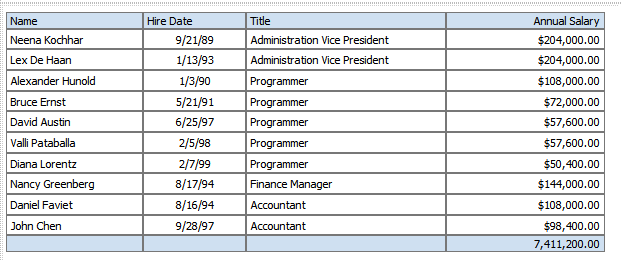

The image presents a table containing employee information, including their names, hire dates, job titles, and annual salaries. Here’s a detailed breakdown of the data:

### Structure of the Table
1. **Columns**:
   - **Name**: The names of the employees.
   - **Hire Date**: The date each employee was hired.
   - **Title**: The job title of each employee.
   - **Annual Salary**: The yearly salary for each employee.

### Employee Details
1. **Neena Kochhar**
   - **Hire Date**: September 21, 1989
   - **Title**: Administration Vice President
   - **Annual Salary**: $204,000.00

2. **Lex De Haan**
   - **Hire Date**: January 13, 1993
   - **Title**: Administration Vice President
   - **Annual Salary**: $204,000.00

3. **Alexander Hunold**
   - **Hire Date**: January 3, 1990
   - **Title**: Programmer
   - **Annual Salary**: $108,000.00

4. **Bruce Ernst**
   - **Hire Date**: May 21, 1991
   - **Title**: Programmer
   - **Annual Salary**: $72,000.00

5. **David Austin**
   - **Hire Date**

In [29]:
# 샘플 이미지 주소(웹사이트로부터 바로 인식)
IMAGE_URL = "https://docs.oracle.com/cd/E80149_01/bip/BIPRD/img/GUID-26851D84-8262-49BC-B049-0E299767A8C5-default.gif"

# 이미지 파일로부터 질문
answer = MultiModal_llm.stream(IMAGE_URL)

# 스트리밍 방식으로 각 토큰을 출력(실시간 출력)
final_answer = stream_response(answer)


In [32]:
# 샘플 이미지 주소(웹사이트로부터 바로 인식)
IMAGE_URL = "https://docs.oracle.com/cd/E80149_01/bip/BIPRD/img/GUID-26851D84-8262-49BC-B049-0E299767A8C5-default.gif"

# 이미지 파일로부터 질문
answer = MultiModal_llm.stream(
    [
        {
            "type" : "text",
            "text" : "이미지의 내용을 한국어로 자세히 설명해줘.이미지 안의 영어 문구가 있다면 한국어로 번역해서 설명해줘."
        },
        {
            "type" : "image_url",
            "image_url": {
                "url" : IMAGE_URL
            }
        }
    ]
)

# 스트리밍 방식으로 각 토큰을 출력(실시간 출력)
final_answer = stream_response(answer)


AttributeError: 'list' object has no attribute 'startswith'